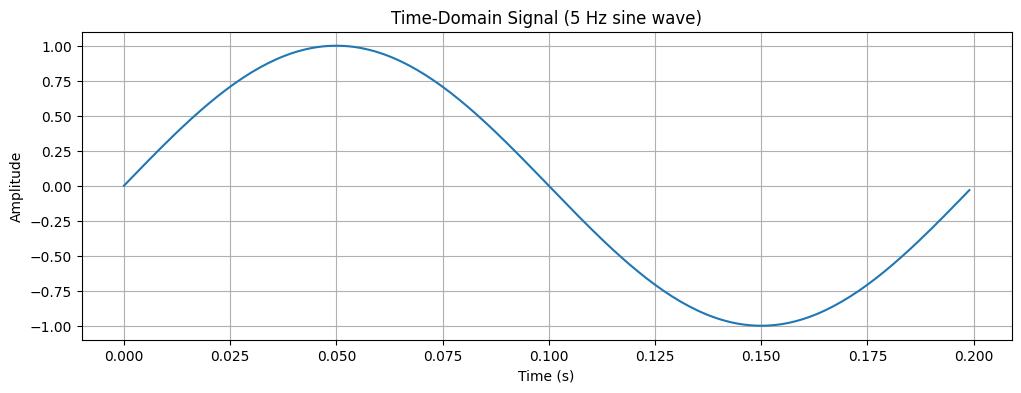

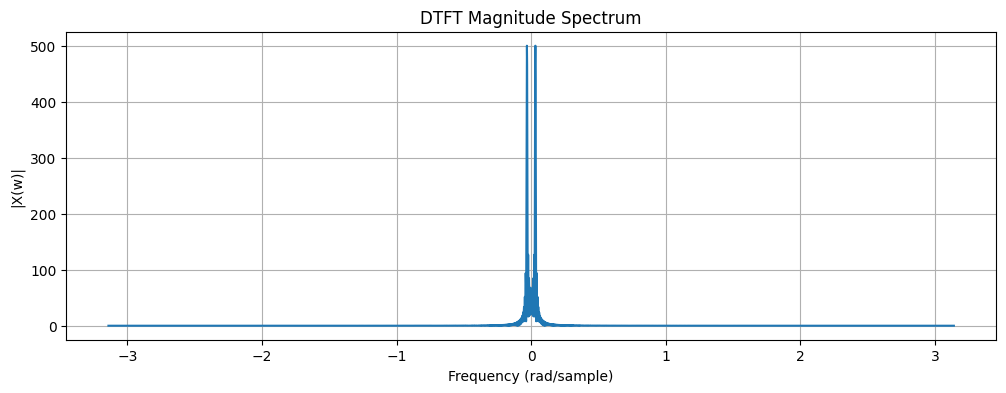

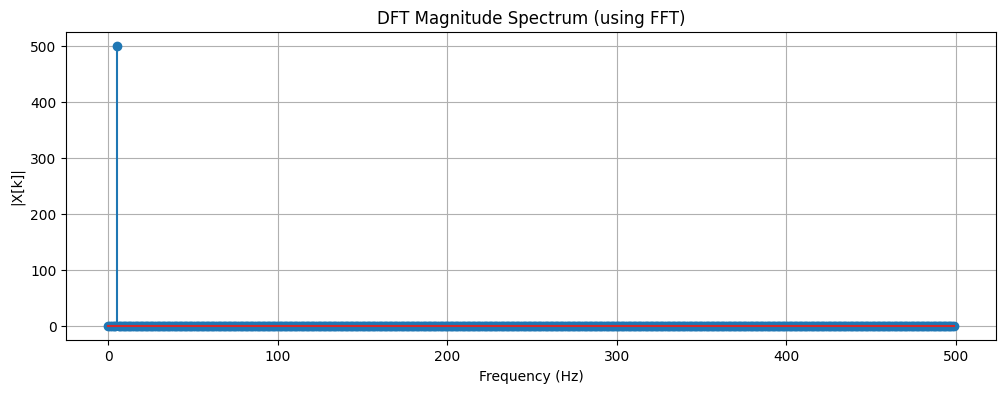

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000   # Sampling frequency (Hz)
f = 5       # Signal frequency (Hz)
N = 1000    # Number of samples
t = np.arange(0, N) / fs  # Time vector

# (a) Generate sinusoidal signal
x = np.sin(2 * np.pi * f * t)
x

# (b) Plot time-domain waveform
plt.figure(figsize=(12, 4))
plt.plot(t[:200], x[:200])  # show only first 200 samples for clarity
plt.title("Time-Domain Signal (5 Hz sine wave)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# (c) Compute DTFT (using freq response approach)
# DTFT is theoretically continuous, but we approximate with dense frequency grid
w = np.linspace(-np.pi, np.pi, 4096)  # frequency grid (radians)
X_dtft = np.array([np.sum(x * np.exp(-1j * w_i * np.arange(N))) for w_i in w])

plt.figure(figsize=(12, 4))
plt.plot(w, np.abs(X_dtft))
plt.title("DTFT Magnitude Spectrum")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("|X(w)|")
plt.grid(True)
plt.show()

# (d) Compute DFT (using FFT)
X_dft = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)  # Frequency axis (Hz)

plt.figure(figsize=(12, 4))
plt.stem(freqs[:N//2], np.abs(X_dft[:N//2]))
plt.title("DFT Magnitude Spectrum (using FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X[k]|")
plt.grid(True)
plt.show()

Time-domain (5 Hz sine) → Smooth sinusoidal wave of amplitude ±1. Sampling at 1000 Hz (≫ Nyquist) avoids aliasing.

DTFT → Shows two sharp peaks at ±ω₀ (≈0.0314 rad/sample), confirming that a pure sine has energy at only one frequency pair.

DFT (FFT) → Displays a single spike at 5 Hz (and its mirror at –5 Hz in full spectrum). Because 5 Hz aligns with an FFT bin, there is no spectral leakage.

Amplitude → Peak magnitude ≈ N/2 = 500 (un-normalized FFT). If normalized, the amplitude would match the time-domain sine.

Conclusion → A sinusoid in time corresponds to discrete frequency components in the spectrum; coherent sampling ensures sharp peaks with no leakage.

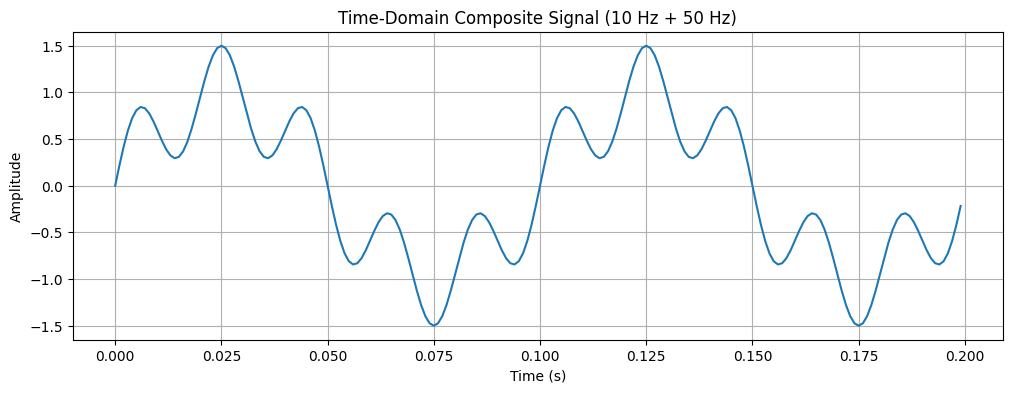

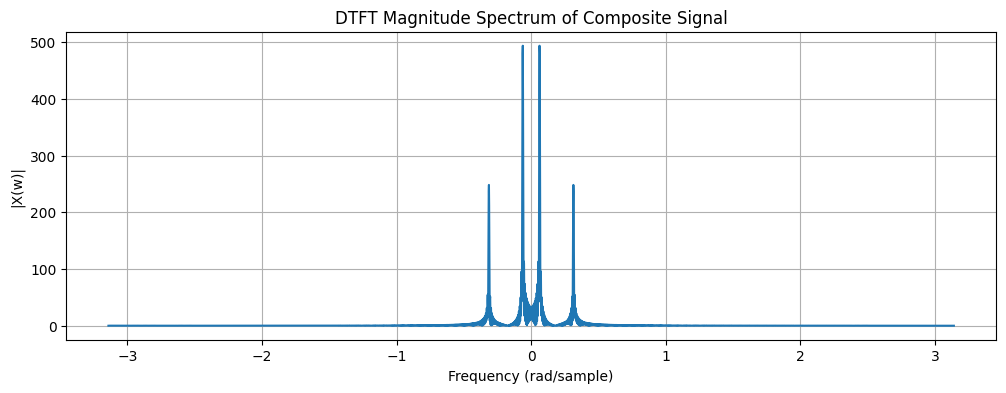

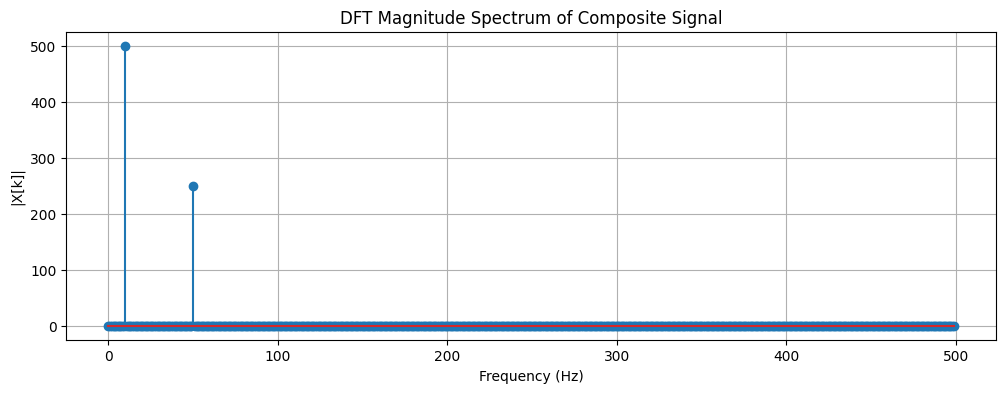

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000   # Sampling frequency (Hz)
N = 1000    # Number of samples
t = np.arange(0, N) / fs  # Time vector

# (a) Generate composite signal: sum of 2 sinusoids
f1, A1 = 10, 1.0   # 10 Hz sine, amplitude 1
f2, A2 = 50, 0.5   # 50 Hz sine, amplitude 0.5
x = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)

# (b) Plot time-domain waveform
plt.figure(figsize=(12, 4))
plt.plot(t[:200], x[:200])  # show first 200 samples for clarity
plt.title("Time-Domain Composite Signal (10 Hz + 50 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# (c) Compute DTFT (approximation with dense frequency grid)
w = np.linspace(-np.pi, np.pi, 4096)  # frequency grid (radians)
X_dtft = np.array([np.sum(x * np.exp(-1j * w_i * np.arange(N))) for w_i in w])

plt.figure(figsize=(12, 4))
plt.plot(w, np.abs(X_dtft))
plt.title("DTFT Magnitude Spectrum of Composite Signal")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("|X(w)|")
plt.grid(True)
plt.show()

# (d) Compute DFT (using FFT)
X_dft = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)  # Frequency axis (Hz)

plt.figure(figsize=(12, 4))
plt.stem(freqs[:N//2], np.abs(X_dft[:N//2]))
plt.title("DFT Magnitude Spectrum of Composite Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X[k]|")
plt.grid(True)
plt.show()

The time-domain signal is a sum of two sinusoids (10 Hz, A=1 and 50 Hz, A=0.5). The result is a slow 10 Hz wave with faster 50 Hz ripples riding on it.

The DTFT shows sharp peaks at ±10 Hz and ±50 Hz. Peak heights match amplitudes (10 Hz stronger than 50 Hz).

The DFT also shows discrete spectral lines at the same frequencies.

Inference: A sum of sinusoids in time gives distinct frequency components in the spectrum, with magnitudes proportional to their amplitudes.

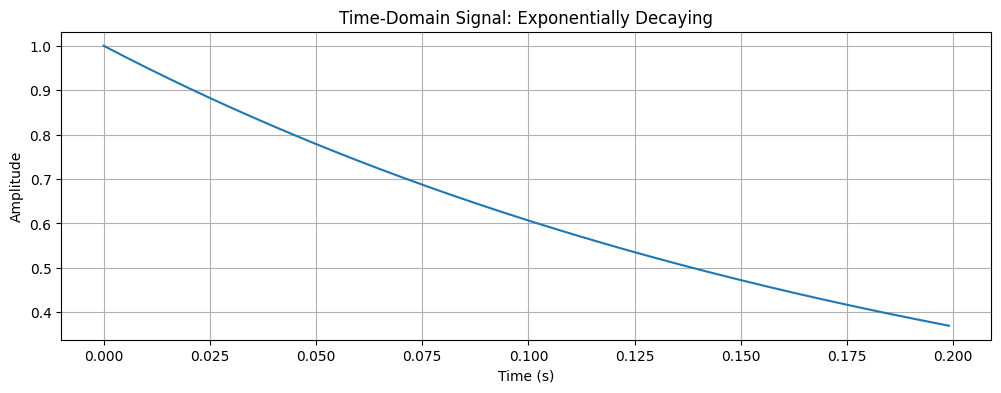

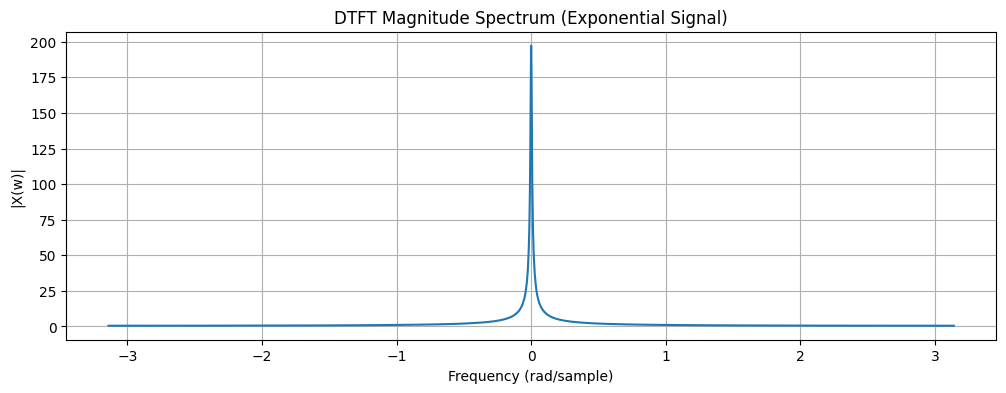

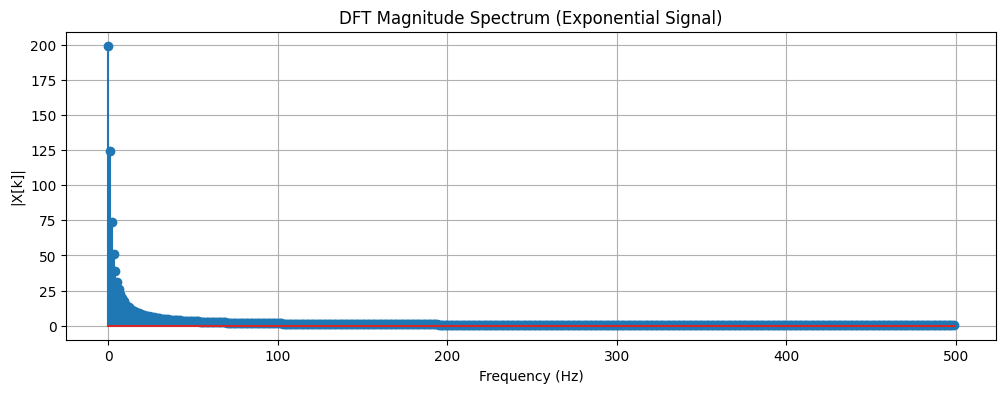

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000   # Sampling frequency (Hz)
N = 1000    # Number of samples
t = np.arange(0, N) / fs  # Time vector

# (a) Generate exponentially decaying signal
alpha = 5   # Decay rate
x = np.exp(-alpha * t)

# (b) Plot time-domain waveform
plt.figure(figsize=(12, 4))
plt.plot(t[:200], x[:200])  # show first 200 samples
plt.title("Time-Domain Signal: Exponentially Decaying")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# (c) Compute DTFT (dense frequency grid)
w = np.linspace(-np.pi, np.pi, 4096)  # frequency grid
X_dtft = np.array([np.sum(x * np.exp(-1j * w_i * np.arange(N))) for w_i in w])

plt.figure(figsize=(12, 4))
plt.plot(w, np.abs(X_dtft))
plt.title("DTFT Magnitude Spectrum (Exponential Signal)")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("|X(w)|")
plt.grid(True)
plt.show()

# (d) Compute DFT (using FFT)
X_dft = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)  # Frequency axis (Hz)

plt.figure(figsize=(12, 4))
plt.stem(freqs[:N//2], np.abs(X_dft[:N//2]))
plt.title("DFT Magnitude Spectrum (Exponential Signal)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X[k]|")
plt.grid(True)
plt.show()

(a)
𝑥
(
𝑡
)
=
𝑒
−
𝛼
𝑡
,

𝛼
>
0
x(t)=e
−αt
, α>0.
(b) Time plot: starts at 1 and decays smoothly to 0 (energy front-loaded).
(c) DTFT: continuous spectrum with a strong peak at 0 rad/sample (DC), decaying with frequency.
(d) DFT: discrete samples of the DTFT — large DC bin, smaller magnitude across higher bins, some leakage from truncation.
(e) Inference: slower decay → more concentrated at low frequencies; faster decay → broader frequency spread.

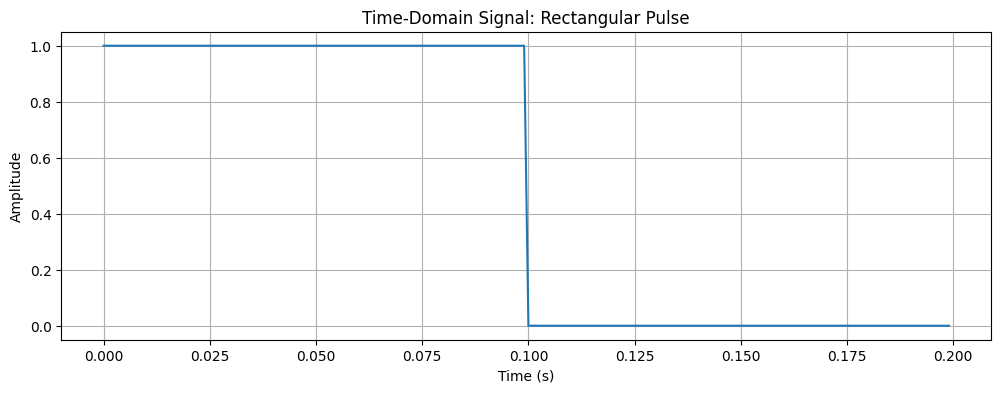

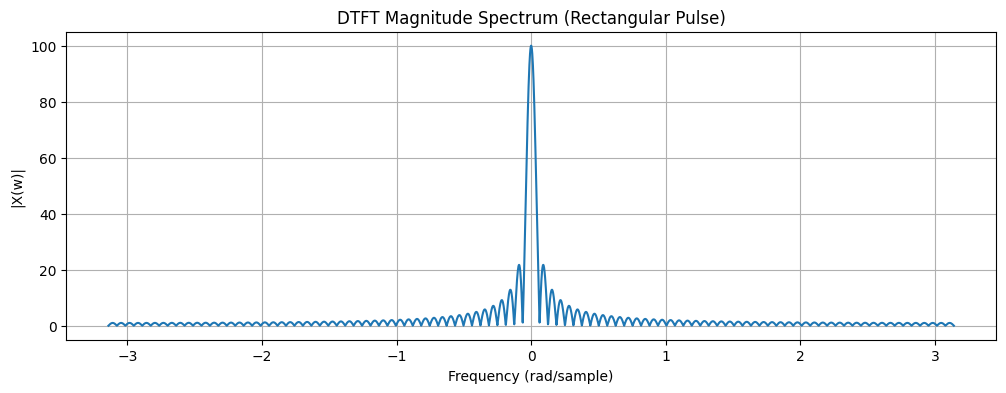

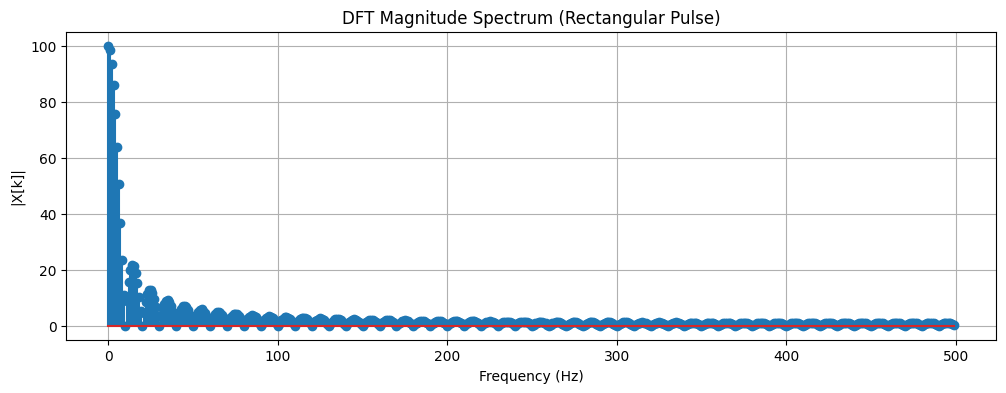

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000   # Sampling frequency (Hz)
N = 1000    # Number of samples
t = np.arange(0, N) / fs  # Time vector

# (a) Generate a rectangular pulse signal
pulse_width = 0.1  # in seconds
x = np.zeros(N)
x[0:int(pulse_width * fs)] = 1  # Rectangular pulse of width = 0.1s

# (b) Plot time-domain waveform
plt.figure(figsize=(12, 4))
plt.plot(t[:200], x[:200])  # show first 200 samples
plt.title("Time-Domain Signal: Rectangular Pulse")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# (c) Compute DTFT (dense frequency grid)
w = np.linspace(-np.pi, np.pi, 4096)  # frequency grid
X_dtft = np.array([np.sum(x * np.exp(-1j * w_i * np.arange(N))) for w_i in w])

plt.figure(figsize=(12, 4))
plt.plot(w, np.abs(X_dtft))
plt.title("DTFT Magnitude Spectrum (Rectangular Pulse)")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("|X(w)|")
plt.grid(True)
plt.show()

# (d) Compute DFT (using FFT)
X_dft = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)  # Frequency axis (Hz)

plt.figure(figsize=(12, 4))
plt.stem(freqs[:N//2], np.abs(X_dft[:N//2]))
plt.title("DFT Magnitude Spectrum (Rectangular Pulse)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X[k]|")
plt.grid(True)
plt.show()

Time-Domain Behavior

The rectangular pulse is a block of constant amplitude
1
1 for a short duration (0.1s in this case).

Outside that duration, the signal is zero.

Frequency-Domain Behavior (DTFT)

The Fourier transform of a rectangular pulse is a sinc function:

𝑋
(
𝑓
)
=
𝐴
⋅
sin
⁡
(
𝜋
𝑓
𝑇
)
𝜋
𝑓
X(f)=A⋅
πf
sin(πfT)
	​


where
𝑇
T is pulse width.

This means most of the energy is concentrated near low frequencies, but there are oscillating side lobes.

DFT Spectrum

The DFT shows sampled values of the sinc shape.

The main lobe is centered at 0 Hz, with side lobes decreasing in amplitude as frequency increases.

Time-Frequency Relationship

Shorter pulse width → wider frequency spread (broad sinc).

Longer pulse width → narrower frequency spread (narrow sinc).

This again illustrates the time-frequency tradeoff: compactness in time leads to spread in frequency.